# Beat travel times (OSRM)

Driving minutes from the center of each Oakland police beat to every address in that beat.

In [2]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import shapely

# 1) find the shared workspace across Box, local, and container mounts
target_rel = Path("OPD & TAN - Core Workspace") / "02 Oakland Police Dept (OPD)"
candidates = []
if os.environ.get("BOX_ROOT"):
    candidates.append(Path(os.environ["BOX_ROOT"]).expanduser())
candidates += [
    Path.home() / "Library/CloudStorage/Box",
    Path.home() / "Library/CloudStorage/Box-Box",
    Path.home() / "Box",
    Path.home() / "Box Sync",
    Path.cwd(),
    *Path.cwd().parents,
    Path("/workspace"),
    Path("/work"),
    Path("/mnt"),
]
seen = set()
roots = []
for candidate in candidates:
    candidate = candidate.expanduser()
    key = str(candidate)
    if key not in seen:
        seen.add(key)
        roots.append(candidate)

BOX_ROOT = next((root.resolve() for root in roots if (root / target_rel).is_dir()), None)
if BOX_ROOT is None:
    raise FileNotFoundError(
        "Could not find 'OPD & TAN - Core Workspace/02 Oakland Police Dept (OPD)'. "
        "Verify Box Drive is logged in, select 'Make Available Offline' in macOS Finder, "
        "or check that the Antigravity session is using the host Python environment. "
        "You can also set os.environ['BOX_ROOT'] to the Box or workspace root."
    )

# 2) project directories
OSRM = "https://router.project-osrm.org" # public demo server: <= 1 req/sec, max 100 coords per table call
OPD  = BOX_ROOT / "OPD & TAN - Core Workspace" / "02 Oakland Police Dept (OPD)"
DATA = OPD / "Data" / "Our Data"     # inputs only
OUT  = OPD / "Outputs"              # anything we produce
OUT.mkdir(parents=True, exist_ok=True)
print(f"connected to {OPD}")

connected to /Users/kurumi/Library/CloudStorage/Box-Box/OPD & TAN - Core Workspace/02 Oakland Police Dept (OPD)


In [3]:
# 1) beat polygons: https://data.oaklandca.gov/Public-Safety/Police-Beats/78s7-673i/about_data
#    59 polygons, lon/lat. "name" = beat code (e.g. "03Y"). LKM1 = Lake Merritt, PDT2 = Piedmont -> dropped.
beats_all = gpd.read_file("https://data.oaklandca.gov/api/geospatial/78s7-673i?method=export&format=GeoJSON")
beats_all = beats_all[["name", "pol_dist", "acres", "geometry"]].rename(columns={"name": "beat", "pol_dist": "area"})
enclaves = beats_all[beats_all["beat"].isin(["LKM1", "PDT2"])].assign(label=["Lake Merritt", "Piedmont"])   # not OPD beats; kept for map labels
beats = beats_all.query("beat not in ['LKM1', 'PDT2']").sort_values("beat").reset_index(drop=True)
# the source layer has 12 tiny stray polygon pieces (69 m squares, some in San Leandro) attached to 5 beats -> keep each beat's main polygon only
beats["geometry"] = beats.geometry.apply(lambda g: max(g.geoms, key=lambda p: p.area) if g.geom_type == "MultiPolygon" else g)
print(len(beats), "beats")
beats.head()

57 beats


,beat,area,acres,geometry
0,01X,1,302.94300000000004,"POLYGON ((-122.27508 37.79812, -122.27463 37.7..."
1,02X,1,612.34,"POLYGON ((-122.28216 37.79627, -122.28389 37.7..."
2,02Y,1,2092.527,"POLYGON ((-122.29152 37.81081, -122.29153 37.8..."
3,03X,1,214.241,"POLYGON ((-122.26221 37.7922, -122.26231 37.79..."
4,03Y,1,125.054,"POLYGON ((-122.27502 37.79821, -122.27508 37.7..."


In [4]:
# 2) all Oakland address points (Alameda County GIS), cached in Box by an earlier pull
#    source: https://www.arcgis.com/home/item.html?id=4610acbf49364583986d45ee4106cc3f
addresses = pd.read_parquet(DATA / "oakland_address_points.parquet")
print(len(addresses), "Oakland address points in Box cache")
addresses = gpd.GeoDataFrame(addresses, geometry=gpd.points_from_xy(addresses["lon"], addresses["lat"]), crs=4326)
addresses = gpd.sjoin(addresses, beats[["beat", "geometry"]], how="inner", predicate="within").drop(columns="index_right")
print(len(addresses), "fall inside one of the 57 beats")
addresses.head()

132144 Oakland address points in Box cache
131923 fall inside one of the 57 beats


,ADDRESS,ZIPCODE,UNIT,APN,lon,lat,geometry,beat
0,2915 Monticello Ave,94619,NaN,036 244200400,-122.196625,37.780706,POINT (-122.19662 37.78071),28X
1,2448 66th Ave,94605,NaN,039 325903600,-122.186778,37.766850,POINT (-122.18678 37.76685),30X
2,9521 Alcala Ave,94605,NaN,043A475000300,-122.151499,37.755634,POINT (-122.1515 37.75563),35X
3,1889 Harrison St Apt 407,94612,407,008 062506400,-122.265949,37.806104,POINT (-122.26595 37.8061),04X
4,1843 E 38th St,94602,NaN,023 049602200,-122.219529,37.802228,POINT (-122.21953 37.80223),16Y


In [6]:
# 2b) address density: low-density beats help distinguish missing data from land-use voids
address_counts = addresses.groupby("beat").size().rename("n_addresses")
density = (beats[["beat", "acres", "geometry"]]
            .merge(address_counts, on="beat", how="left")
            .assign(n_addresses=lambda d: d["n_addresses"].fillna(0).astype(int)))
density["acres"] = pd.to_numeric(density["acres"], errors="coerce")
density["addresses_per_acre"] = density["n_addresses"] / density["acres"]
print("bottom 10 beats by address density")
density[["beat", "n_addresses", "acres", "addresses_per_acre"]].sort_values("addresses_per_acre").head(10)
# visual gaps correspond to filtered enclaves (LKM1 Lake Merritt water body, PDT2 Piedmont enclave),
# unaddressed industrial/transport infrastructure (Port of Oakland, rail yards, Coliseum, Airport),
# and protected open space in the East Bay Regional Park District (Redwood, Joaquin Miller, Chabot).
# Hill beats such as 13Y, 22Y, 25Y, and 35Y include these regional parks.

bottom 10 beats by address density


,beat,n_addresses,acres,addresses_per_acre
48,31X,143,13616.028,0.010502
7,05Y,851,1866.395,0.455959
9,07X,2193,3284.273,0.667728
2,02Y,1796,2092.527,0.858292
40,26X,696,753.560,0.923616
56,35Y,2629,2689.367,0.977553
39,25Y,2334,1924.476,1.212798
18,13Y,4057,2789.632,1.454314
1,02X,1323,612.340,2.160564
49,31Y,1603,734.246,2.183192


In [7]:
# 3) distance from each address to its beat's boundary (kept as a column so we can split edge vs interior later)
addr_m  = addresses.to_crs(26910)                                      # meters (UTM 10N)
bound_m = beats.set_index("beat").to_crs(26910).geometry.boundary
addresses["dist_to_edge_m"] = shapely.distance(addr_m.geometry.values, bound_m.loc[addr_m["beat"]].values)
print(f"{(addresses['dist_to_edge_m'] <= 100).sum():,} of {len(addresses):,} addresses are within 100 m of a beat edge")
addresses.head()

35,283 of 131,923 addresses are within 100 m of a beat edge


,ADDRESS,ZIPCODE,UNIT,APN,lon,lat,geometry,beat,dist_to_edge_m
0,2915 Monticello Ave,94619,NaN,036 244200400,-122.196625,37.780706,POINT (-122.19662 37.78071),28X,359.507112
1,2448 66th Ave,94605,NaN,039 325903600,-122.186778,37.766850,POINT (-122.18678 37.76685),30X,24.333470
2,9521 Alcala Ave,94605,NaN,043A475000300,-122.151499,37.755634,POINT (-122.1515 37.75563),35X,173.594734
3,1889 Harrison St Apt 407,94612,407,008 062506400,-122.265949,37.806104,POINT (-122.26595 37.8061),04X,285.272983
4,1843 E 38th St,94602,NaN,023 049602200,-122.219529,37.802228,POINT (-122.21953 37.80223),16Y,146.409020


In [8]:
# 4) beat centers: centroid (falls back to a guaranteed-inside point for odd shapes). OSRM snaps it to the nearest road.
cen = beats.to_crs(26910).geometry.centroid
inside = cen.within(beats.to_crs(26910).geometry)
cen[~inside] = beats.to_crs(26910).geometry.representative_point()[~inside]
beats["center"] = cen.to_crs(4326)
beats["center_lon"] = beats["center"].x
beats["center_lat"] = beats["center"].y
beats[["beat", "center_lon", "center_lat"]].head()

,beat,center_lon,center_lat
0,01X,-122.273127,37.793888
1,02X,-122.289577,37.800513
2,02Y,-122.325203,37.804385
3,03X,-122.266758,37.798545
4,03Y,-122.276585,37.802748


In [9]:
# 5) OSRM: center -> EVERY address in the beat. Demo server caps URL length (~400 coords/call), so destinations go in chunks.
#    ~130k addresses / 350 = ~430 calls at 1 req/sec -> ~8 min. (self-hosted OSRM would do this in seconds)
CHUNK = 350

def osrm_center_to(beat, dests):
    c = beats.loc[beats["beat"] == beat].iloc[0]
    coords = ";".join([f"{c['center_lon']:.6f},{c['center_lat']:.6f}"] + [f"{lon:.6f},{lat:.6f}" for lon, lat in zip(dests["lon"], dests["lat"])])
    r = requests.get(f"{OSRM}/table/v1/driving/{coords}", params={"sources": "0", "annotations": "duration,distance"}, timeout=60)
    r.raise_for_status()
    js = r.json()
    out = dests[["beat", "ADDRESS", "lon", "lat", "dist_to_edge_m"]].copy()
    out["minutes"] = np.array(js["durations"][0][1:], dtype=float) / 60
    out["km"]      = np.array(js["distances"][0][1:], dtype=float) / 1000
    return out

RERUN_OSRM = False   # True = call OSRM again (~8-18 min on the demo server). False = load the last run saved in Box Outputs.

if RERUN_OSRM:
    results, n_calls = [], 0
    for beat in beats["beat"]:
        a = addresses[addresses["beat"] == beat]
        for start in range(0, len(a), CHUNK):
            results.append(osrm_center_to(beat, a.iloc[start:start + CHUNK]))
            n_calls += 1
            time.sleep(1.1)                   # demo-server rate limit (1 req/s)
    results = pd.concat(results, ignore_index=True)
    print(f"{len(results):,} center->address travel times from {n_calls} OSRM calls")
else:
    results = pd.read_parquet(OUT / "beat_center_to_addresses_times.parquet")
    print(f"{len(results):,} center->address travel times loaded from last run")
results.head()

131,923 center->address travel times loaded from last run


,beat,ADDRESS,lon,lat,dist_to_edge_m,minutes,km
0,01X,277 5th St,-122.271092,37.796299,28.481148,2.356667,1.3412
1,01X,568 3rd St,-122.278656,37.798104,142.463308,3.018333,1.8979
2,01X,401 Alice St,-122.270883,37.795928,57.104487,1.775000,1.1272
3,01X,311 2nd St Unit 702,-122.273373,37.794668,280.005342,2.463333,1.4327
4,01X,40 Harrison St Apt 257,-122.273159,37.793519,273.195138,5.580000,4.1410


In [11]:
# 5b) station facilities -> EVERY Oakland address, using the same chunked OSRM table calls
facilities = pd.DataFrame([
    {"lon": -122.27475, "lat": 37.79948, "beat": "03Y", "facility": "PAB"},
    {"lon": -122.17543, "lat": 37.76750, "beat": "30Y", "facility": "Eastmont"},
])

def osrm_facility_to(facility_row, dests):
    coords = ";".join([f"{facility_row['lon']:.6f},{facility_row['lat']:.6f}"] + [f"{lon:.6f},{lat:.6f}" for lon, lat in zip(dests["lon"], dests["lat"])])
    r = requests.get(f"{OSRM}/table/v1/driving/{coords}", params={"sources": "0", "annotations": "duration,distance"}, timeout=60)
    r.raise_for_status()
    js = r.json()
    out = dests[["beat", "ADDRESS", "lon", "lat", "dist_to_edge_m"]].copy()
    out["facility"] = facility_row["facility"]
    out["minutes"] = np.array(js["durations"][0][1:], dtype=float) / 60
    out["km"] = np.array(js["distances"][0][1:], dtype=float) / 1000
    return out

facility_cache = OUT / "facility_to_addresses_times.parquet"
RERUN_FACILITIES = False   # True = call OSRM again; missing caches are generated automatically.

if RERUN_FACILITIES or not facility_cache.exists():
    facility_results, n_calls = [], 0
    for _, facility_row in facilities.iterrows():
        for start in range(0, len(addresses), CHUNK):
            facility_results.append(osrm_facility_to(facility_row, addresses.iloc[start:start + CHUNK]))
            n_calls += 1
            time.sleep(1.1)
    facility_results = pd.concat(facility_results, ignore_index=True)
    facility_results.to_parquet(facility_cache, index=False)
    print(f"{len(facility_results):,} facility->address travel times from {n_calls} OSRM calls")
else:
    facility_results = pd.read_parquet(facility_cache)
    print(f"{len(facility_results):,} facility->address travel times loaded from last run")

facility_summary = (facility_results.groupby(["facility", "beat"])["minutes"]
                    .agg(n="size", median_min="median", p90_min=lambda s: s.quantile(.9), max_min="max")
                    .round(1).reset_index())
print("facility travel-time summary by beat")
facility_summary.head()

263,846 facility->address travel times from 754 OSRM calls
facility travel-time summary by beat


,facility,beat,n,median_min,p90_min,max_min
0,Eastmont,01X,2627,11.6,12.6,16.5
1,Eastmont,02X,1323,13.7,14.5,18.6
2,Eastmont,02Y,1796,15.0,15.8,22.8
3,Eastmont,03X,2974,12.4,13.0,13.4
4,Eastmont,03Y,849,13.0,13.2,13.9


In [12]:
# 5c) cache facility results for later maps and calibration
if RERUN_FACILITIES:
    facility_results.to_parquet(OUT / "facility_to_addresses_times.parquet", index=False)
facility_results.head()

,beat,ADDRESS,lon,lat,dist_to_edge_m,facility,minutes,km
0,28X,2915 Monticello Ave,-122.196625,37.780706,359.507112,PAB,11.126667,9.4236
1,30X,2448 66th Ave,-122.186778,37.766850,24.333470,PAB,11.583333,10.0451
2,35X,9521 Alcala Ave,-122.151499,37.755634,173.594734,PAB,14.780000,14.8776
3,04X,1889 Harrison St Apt 407,-122.265949,37.806104,285.272983,PAB,3.090000,1.3810
4,16Y,1843 E 38th St,-122.219529,37.802228,146.409020,PAB,8.185000,6.0458


In [13]:
# 6) per-beat summary (minutes from center to every address)
summary = (results.groupby("beat")["minutes"]
                  .agg(n="size", median="median", p90=lambda s: s.quantile(.9), max="max")
                  .round(1).reset_index()
                  .merge(beats[["beat", "area", "acres", "center_lon", "center_lat"]], on="beat"))
print("citywide: median", summary["median"].median(), "min | worst beat max", summary["max"].max(), "min")
summary.sort_values("max", ascending=False).head(10)

citywide: median 1.9 min | worst beat max 24.7 min


,beat,n,median,p90,max,area,acres,center_lon,center_lat
7,05Y,851,13.1,13.8,24.7,1,1866.395,-122.324300,37.816063
9,07X,2193,15.4,16.1,17.5,1,3284.273,-122.326542,37.827771
18,13Y,4057,7.9,10.4,15.0,2,2789.632,-122.225390,37.859502
2,02Y,1796,4.6,5.3,13.2,1,2092.527,-122.325203,37.804385
56,35Y,2629,4.6,6.9,11.3,6,2689.367,-122.133566,37.751278
39,25Y,2334,6.4,9.7,11.0,4,1924.476,-122.150274,37.786887
48,31X,143,7.4,8.7,10.0,6,13616.028,-122.224506,37.693147
50,31Z,1415,2.1,3.0,9.4,6,295.576,-122.178946,37.730686
34,22Y,3473,6.3,7.4,9.3,4,1327.376,-122.188220,37.805445
17,13X,2661,2.5,3.4,9.0,2,981.25,-122.235336,37.839146


In [14]:
# 6a) CAD calibration: compare observed transit time with OSRM free-flow time
cad = pd.read_parquet(DATA / "harmonized_calls_2021_2026.parquet")
print("CAD columns:", list(cad.columns))

cad_cols = {str(c).lower().replace(" ", "_"): c for c in cad.columns}
def find_cad_col(*names):
    return next((cad_cols[name.lower().replace(" ", "_")] for name in names if name.lower().replace(" ", "_") in cad_cols), None)

cad_beat_col = find_cad_col("beat", "Beat")
dispatch_col = find_cad_col("dispatch_time", "DispatchTime")
arrival_col = find_cad_col("arrival_time", "ArrivalTime", "received_time", "ReceivedTime")
enroute_col = find_cad_col("FirstUnitEnrouteTime", "first_unit_enroute_time")

if cad_beat_col and ((dispatch_col and arrival_col) or (arrival_col and enroute_col)):
    cad["beat"] = cad[cad_beat_col].astype(str)
    if dispatch_col and arrival_col:
        cad["observed_minutes"] = (pd.to_datetime(cad[arrival_col], errors="coerce") - pd.to_datetime(cad[dispatch_col], errors="coerce")).dt.total_seconds() / 60
        cad_transit_label = f"{arrival_col} - {dispatch_col}"
    else:
        cad["observed_minutes"] = (pd.to_datetime(cad[enroute_col], errors="coerce") - pd.to_datetime(cad[arrival_col], errors="coerce")).dt.total_seconds() / 60
        cad_transit_label = f"{enroute_col} - {arrival_col}"
    cad = cad.loc[cad["observed_minutes"].between(0, 180)]
    cad_summary = (cad.groupby("beat")["observed_minutes"]
                   .agg(cad_n="size", cad_median_min="median", cad_p90_min=lambda s: s.quantile(.9))
                   .reset_index())
    calibration = (summary[["beat", "median"]].rename(columns={"median": "osrm_median_min"})
                   .merge(cad_summary, on="beat", how="inner"))
    calibration["cad_to_osrm_ratio"] = calibration["cad_median_min"] / calibration["osrm_median_min"]
    calibration["cad_minus_osrm_min"] = calibration["cad_median_min"] - calibration["osrm_median_min"]
    print(f"CAD transit definition: {cad_transit_label}")
    print("CAD median / OSRM free-flow median by beat")
    calibration.sort_values("cad_to_osrm_ratio", ascending=False).head(10)
else:
    calibration = pd.DataFrame()
    print("CAD timestamp or beat columns were not found; inspect the columns above before calibration.")
# OSRM is free-flow driving, so its roughly 2-5 minute trip is only the travel component of 911 delay.

CAD columns: ['agency', 'event_number', 'address', 'beat', 'call_source', 'priority', 'event_time', 'dispatch_time', 'arrival_time', 'incident_type_code', 'incident_type_desc', 'disposition_code', 'disposition_text', 'source_sheet']
CAD transit definition: arrival_time - dispatch_time
CAD median / OSRM free-flow median by beat


Matplotlib is building the font cache; this may take a moment.


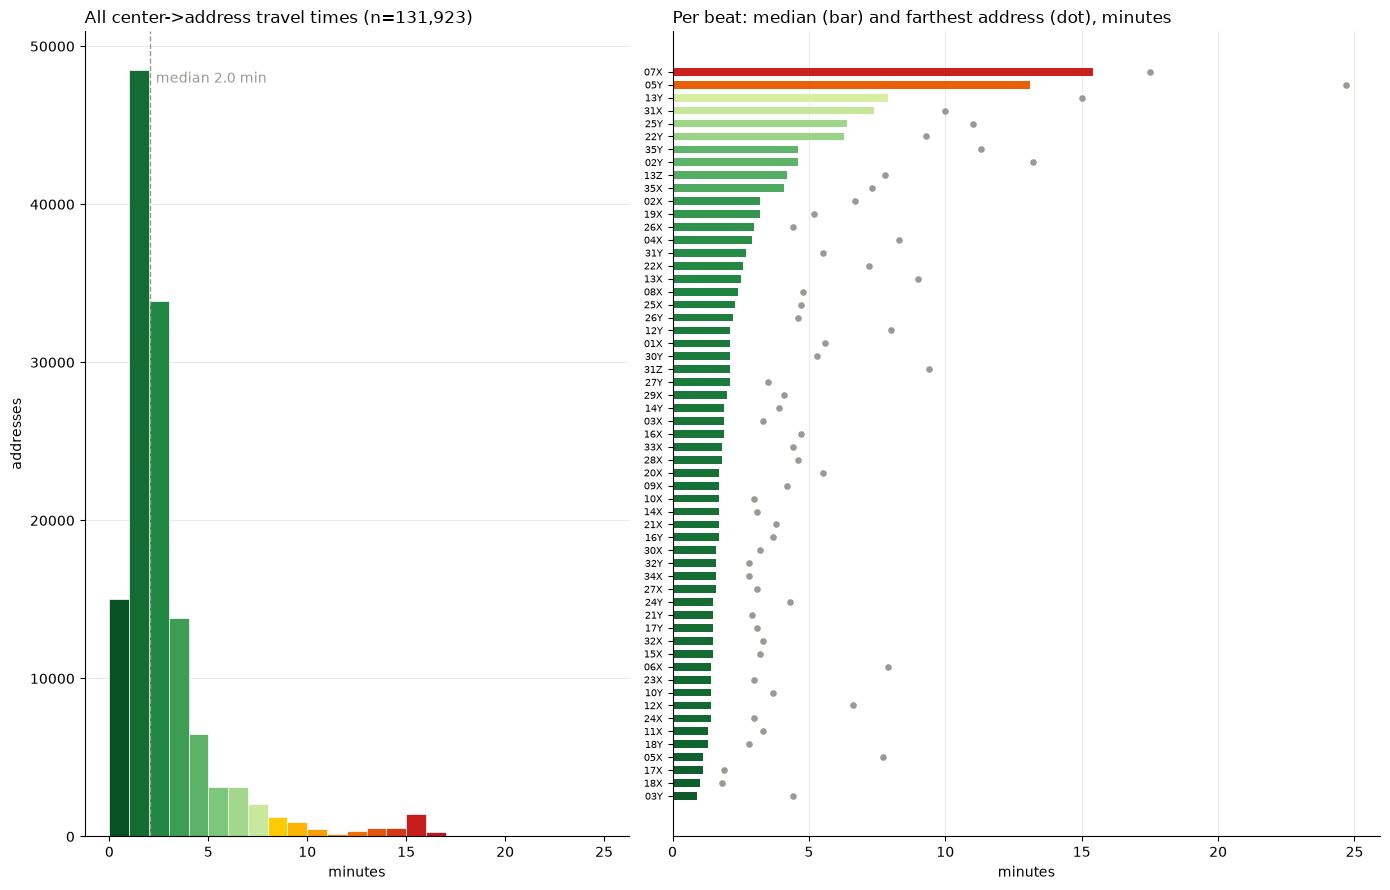

In [15]:
# 6b) distribution of travel times
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# color scale: dark green at 0 -> light yellow-green at 8 (hard cutoff), then yellow -> orange -> red for 8-16+
from matplotlib.colors import ListedColormap
VMAX = 16
greens = LinearSegmentedColormap.from_list("g", ["#00441b", "#238b45", "#74c476", "#d9f0a3"])(np.linspace(0, 1, 128))   # 0-8 min
hots   = LinearSegmentedColormap.from_list("h", ["#ffd600", "#f77f00", "#c1121f"])(np.linspace(0, 1, 128))              # 8-16 min
CMAP = ListedColormap(np.vstack([greens, hots]), name="mins")
CMAP.set_over("#c1121f")
NORM = Normalize(vmin=0, vmax=VMAX)
GREY = "#9a9a94"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 9), gridspec_kw={"width_ratios": [1, 1.3]})

# left: all center->address times, bars colored on the same scale
bins = np.arange(0, results["minutes"].max() + 1, 1)
counts, edges_, patches = ax1.hist(results["minutes"].dropna(), bins=bins, edgecolor="white", linewidth=.5)
for p, left in zip(patches, edges_[:-1]):
    p.set_facecolor(CMAP(NORM(left + .5)))
med = results["minutes"].median()
ax1.axvline(med, color=GREY, linestyle="--", linewidth=1)
ax1.text(med + .3, ax1.get_ylim()[1] * .95, f"median {med:.1f} min", color=GREY, va="top")
ax1.set_title(f"All center->address travel times (n={results['minutes'].notna().sum():,})", loc="left")
ax1.set_xlabel("minutes"); ax1.set_ylabel("addresses")

# right: per beat, median (bar, colored by value) and farthest address (dot), sorted by median
s = summary.sort_values("median")
y = np.arange(len(s))
ax2.barh(y, s["median"], color=[CMAP(NORM(v)) for v in s["median"]], height=.6)
ax2.scatter(s["max"], y, color=GREY, s=14, zorder=3)
ax2.set_yticks(y); ax2.set_yticklabels(s["beat"], fontsize=7)
ax2.set_title("Per beat: median (bar) and farthest address (dot), minutes", loc="left")
ax2.set_xlabel("minutes")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x" if ax is ax2 else "y", color="#e6e6e3", linewidth=.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT / "beat_center_to_addresses_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

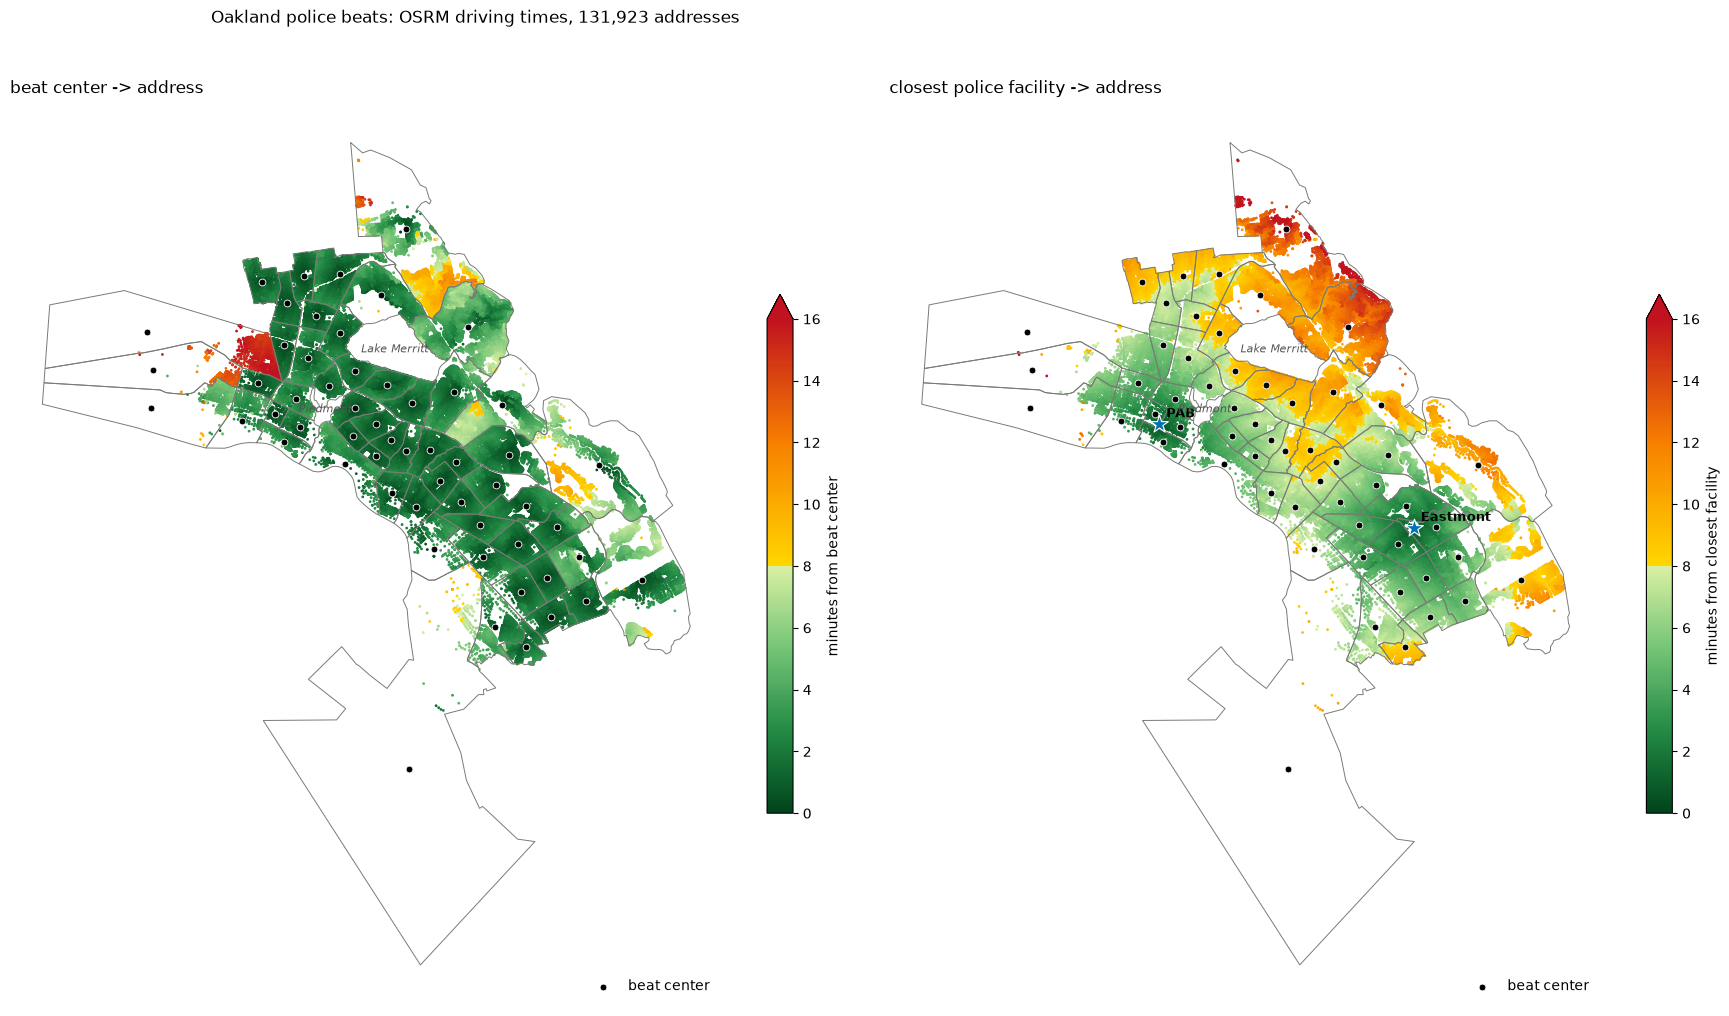

In [16]:
# 6c) maps: compare beat-center and closest-facility driving times
facility_closest = (facility_results.loc[facility_results.groupby(["beat", "ADDRESS", "lon", "lat"])["minutes"].idxmin()]
                    .rename(columns={"minutes": "facility_minutes"}))
map_results = results.merge(facility_closest[["beat", "ADDRESS", "lon", "lat", "facility", "facility_minutes"]],
                            on=["beat", "ADDRESS", "lon", "lat"], how="left")
pts_center = gpd.GeoDataFrame(map_results, geometry=gpd.points_from_xy(map_results["lon"], map_results["lat"]), crs=4326)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 11))
for ax, column, title, label in [
    (ax1, "minutes", "beat center -> address", "minutes from beat center"),
    (ax2, "facility_minutes", "closest police facility -> address", "minutes from closest facility"),
]:
    beats.boundary.plot(ax=ax, color="#7a7a75", linewidth=.7)
    pts_center.plot(ax=ax, column=column, cmap=CMAP, norm=NORM, markersize=1,
                    legend=True, legend_kwds={"label": label, "shrink": .5, "extend": "max"})
    ax.scatter(beats["center_lon"], beats["center_lat"], color="black", edgecolor="white", linewidth=.6,
               s=24, zorder=5, label="beat center")
    ax.set_title(title, loc="left")
    ax.set_aspect(1 / np.cos(np.radians(37.8)))
    ax.set_axis_off()
    ax.legend(loc="lower right", frameon=False)

for _, facility_row in facilities.iterrows():
    ax2.scatter(facility_row["lon"], facility_row["lat"], marker="*", s=180, color="#0072b2",
                edgecolor="white", linewidth=.8, zorder=6, label=facility_row["facility"])
    ax2.annotate(facility_row["facility"], (facility_row["lon"], facility_row["lat"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight="bold")
for _, e in enclaves.iterrows():
    c = e.geometry.centroid
    ax1.annotate(e["label"], (c.x, c.y), ha="center", va="center", fontsize=8, color="#555", style="italic")
    ax2.annotate(e["label"], (c.x, c.y), ha="center", va="center", fontsize=8, color="#555", style="italic")
fig.suptitle(f"Oakland police beats: OSRM driving times, {len(pts_center):,} addresses", x=.12, ha="left")
plt.tight_layout()
plt.savefig(OUT / "beat_center_vs_closest_facility_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# 7) save for mapping later
results.to_parquet(OUT / "beat_center_to_addresses_times.parquet", index=False)
summary.to_csv(OUT / "beat_center_to_addresses_summary.csv", index=False)
facility_summary.to_csv(OUT / "facility_to_addresses_summary.csv", index=False)
print("saved to", OUT)

saved to /Users/kurumi/Library/CloudStorage/Box-Box/OPD & TAN - Core Workspace/02 Oakland Police Dept (OPD)/Outputs


In [ ]:
# NOTES
# - Travel times are OSRM free-flow civilian driving (OpenStreetMap roads), not police response. Calibration idea:
#   CAD observed drive time = arrival_time - dispatch_time (harmonized_calls_2021_2026.parquet; 2026 sheet also has
#   FirstUnitEnrouteTime -> arrived - enroute is cleaner). Fit a per-beat/per-hour factor and scale OSRM minutes.
# - CAD has no unit id / unit location / coordinates -> we cannot know where the responding car actually started.
# - OPD has no live officer locations (audit p.63: patrol-car GPS installed, not activated). Beat boundaries unchanged since 2020.
# - OPD facilities if we want station origins: Police Admin Bldg 455 7th St (-122.27475, 37.79948, beat 03Y);
#   Eastmont Substation 2701 73rd Ave (-122.17543, 37.76750, beat 30Y).
# - Coordinate order: OSRM/GeoJSON = lon,lat ; Google = lat,lng. OSRM durations are seconds.